# Exploratory Data Analysis (EDA) Adult Income Dataset

This project performs data cleaning and exploratory data analysis (EDA) on the Adult Income dataset to understand patterns affecting income levels.

In [35]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats import chi2_contingency

In [36]:
# loading the dataset

df = pd.read_csv("../data/raw_data.csv")

## Data cleaning

### Standardise column names and strings values

In [37]:
# clean column names
df.columns = df.columns.str.lower().str.strip().str.replace("-", "_", regex=False)

# clean text values
for col in df.select_dtypes(include=["object", "string"]).columns:
    df[col] = df[col].str.lower().str.strip().str.replace("-", "_", regex=False)


### Handling missing values

In [38]:
# replace "?" with NaN
df = df.replace("?", pd.NA)

- Missing values originally represented as "?" were converted to NaN

In [39]:
# fill missing categorical values
df["workclass"] = df["workclass"].fillna("unknown")
df["occupation"] = df["occupation"].fillna("unknown")
df["native_country"] = df["native_country"].fillna("unknown")


- Missing values detected in workclass, occupation, native_country  
- Filled with "unknown" to preserve data instead of dropping rows  
- No inconsistencies found in categorical values (case sensitivity or spacing)

### Fixing target variable (Income)

In [40]:
# clean and convert income
# ensure column is string (prevents .str errors on rerun)
df["income"] = df["income"].astype(str)
df["income"] = df["income"].str.strip().str.replace(".", "", regex=False)
df["income"] = df["income"].map({"<=50k": 0, ">50k": 1})
df["income"] = df["income"].astype("Int64") ## convert to Int64

- Income converted to binary format (0 = <=50K, 1 = >50K)

### Data Type Conversion

In [41]:
# convert categorical columns 
cat_col = df.select_dtypes(include=["object", "string"]).columns
df[cat_col] = df[cat_col].astype("category")

- Converted object columns to category dtype for memory efficiency

### Dropping irrelevant column

In [42]:
df = df.drop(columns=["fnlwgt"])

- fnlwgt represents census sampling weight, not an actual personal attribute Dropped as it does not contribute meaningful signal for prediction

### Remove Duplicates


In [43]:
df = df.drop_duplicates()

## Outlier handling

### Key Insights (Outliers)

- Age shows a few high-end outliers (>80), while most values lie within a typical adult range  
- Capital_gain and capital_loss contain extreme outliers, with most observations concentrated at 0 and a few very large values  
- Hours_per_week shows mild outliers on both lower (<20) and higher (>60) ends  

Outliers were not removed as they represent valid real-world observations rather than data errors

In [45]:
# save cleaned dataset
df.to_csv("../data/cleaned_data.csv", index=False)

## Univariate analysis

### Key Insights (Distribution)

- Age shows a moderately right-skewed distribution, with most individuals concentrated between 25–50  
- Hours_per_week is strongly centered around 40 hours, indicating a standard full-time work pattern with minor variation  
- Capital_gain and capital_loss are highly right-skewed, with a dominant spike at 0 and very few high-value observations  
- Both capital features are sparse and non-normally distributed, suggesting limited variability for most individuals  

### Education_num Distribution (ORDINAL DATA)


Text(0, 0.5, 'Count')

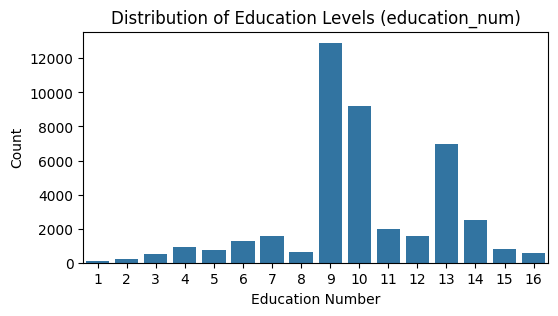

In [47]:
# Countplot Education_num(Ordinal_data)

plt.figure(figsize=(6,3))
sns.countplot(x='education_num', data=df, order=sorted(df['education_num'].unique()))

plt.title("Distribution of Education Levels (education_num)")
plt.xlabel("Education Number")
plt.ylabel("Count")


- Education_num is concentrated between 9–13, indicating most individuals have mid-level education (high school to some college)
- The distribution shows fewer individuals at both lower and higher ends of the education scale  

### Income Distribution

Text(0, 0.5, 'Count')

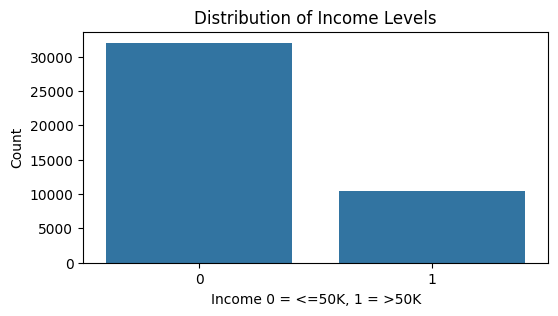

In [48]:
# Income countplot

plt.figure(figsize=(6,3))
sns.countplot(x='income', data=df)

plt.title("Distribution of Income Levels")
plt.xlabel("Income 0 = <=50K, 1 = >50K")
plt.ylabel("Count")


- Income distribution is imbalanced, with a significantly higher proportion of individuals earning <=50K compared to >50K

### Correlation 

Text(0.5, 1.0, 'Correlation Matrix')

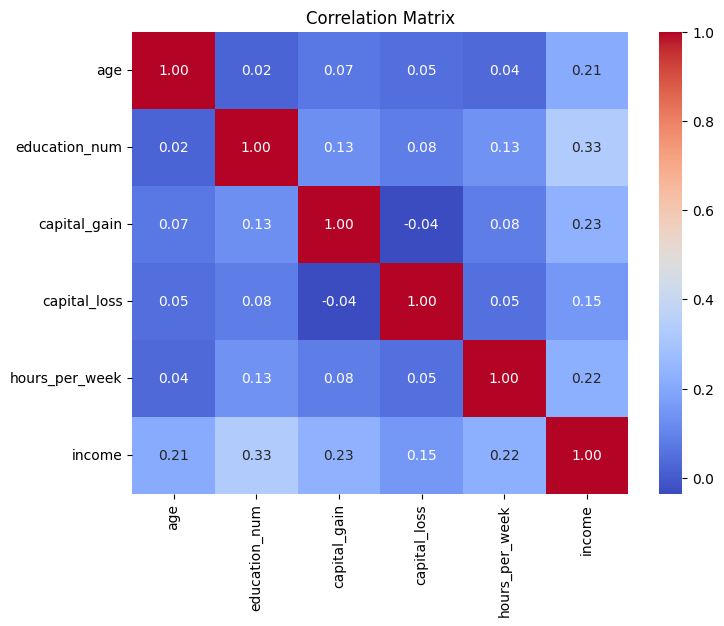

In [49]:
# Compute correlation matrix
corr = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")

In [ ]:
cols = ["age", "education_num", "capital_gain", "capital_loss", "hours_per_week"]

for col in cols:
    r, p_value = pearsonr(df[col], df["income"])
    print(f"r{r: .3f} {col} p_value = {p_value: .4f}")

- All features show positive but weak correlation with income → no strong linear driver
- education_num (0.33) → strongest positive correlation → higher education = higher income
- capital_gain (0.23), hours_per_week (0.22), age (0.21) → moderate influence
capital_loss (0.15) → weakest, minimal impact
- p-value = 0.0000 → all relationships are statistically significant (not random)

### Categorical Features relationship to income (Chi-Square + Cramér’s V)

In [ ]:
cat_cols = ["workclass", "education", "marital_status", "occupation", "relationship", "race", "sex", "native_country"]


for col in cat_cols:
    table = pd.crosstab(df[col], df["income"])
    
    chi2, p, dof, expected = chi2_contingency(table)
    n = table.sum().sum()
    v = np.sqrt(chi2 / n)
    
    print(f"{col}--p_value = {p:.4f}, Cramér’s V = {v:.3f}")

- All variables are statistically  significant (p < 0.05)
- Strongest: relationship (0.453), marital_status (0.445)
- Moderate: education (0.362), occupation (0.338)
- Low-moderate: sex (0.212), workclass (0.179)
- Weak: race (0.109), native_country (0.103)

- Income shows strongest association with relationship and marital_status, followed by education and occupation

## Bivariate Analysis, Key patterns and Anomalies

### relationship vs income

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'husband'),
  Text(1, 0, 'not_in_family'),
  Text(2, 0, 'other_relative'),
  Text(3, 0, 'own_child'),
  Text(4, 0, 'unmarried'),
  Text(5, 0, 'wife')])

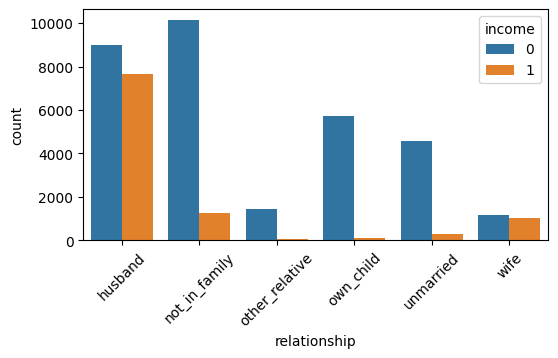

In [52]:
plt.figure(figsize=(6,3))
sns.countplot(x="relationship", hue="income", data=df)
plt.xticks(rotation=45)

- Husband category shows the highest proportion of >50K, while Own-child & Not-in-family are mostly in ≤50K → relationship strongly influences income
- ANOMALY: Some Husband individuals still fall under ≤50K, indicating other factors affect income

### marital_status vs income

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'divorced'),
  Text(1, 0, 'married_af_spouse'),
  Text(2, 0, 'married_civ_spouse'),
  Text(3, 0, 'married_spouse_absent'),
  Text(4, 0, 'never_married'),
  Text(5, 0, 'separated'),
  Text(6, 0, 'widowed')])

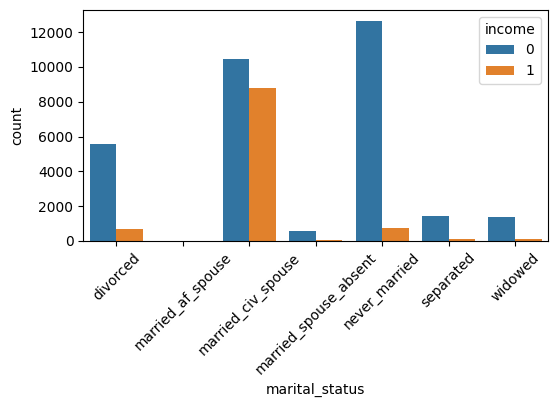

In [53]:
plt.figure(figsize=(6,3))
sns.countplot(x="marital_status", hue="income", data=df)
plt.xticks(rotation=45)

- Married individuals show a higher proportion of >50K income, Never-married individuals are mostly in the ≤50K category
- ANOMALY = Some never-married individuals still earn >50K, indicating other factors like education or occupation play a role

### education vs income

<Axes: xlabel='count', ylabel='education'>

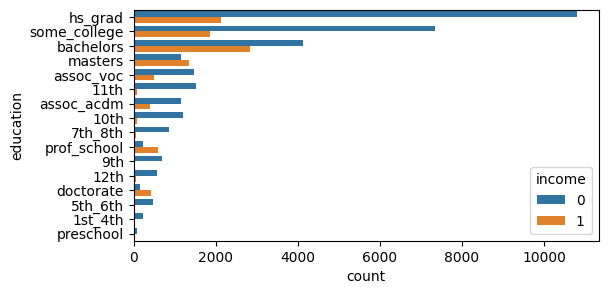

In [54]:
plt.figure(figsize=(6,3))
sns.countplot(y="education", hue="income", data=df, order=df["education"].value_counts().index)


- Higher education levels (Bachelors, Masters, Doctorate) show higher proportion of >50K
- Lower education levels are dominated by <=50, Education is a strong upward driver of income.
- ANAMOLY = Some highly educated individuals still earn <=50K, showing education alone is not sufficient

### occupation vs income

<Axes: xlabel='count', ylabel='occupation'>

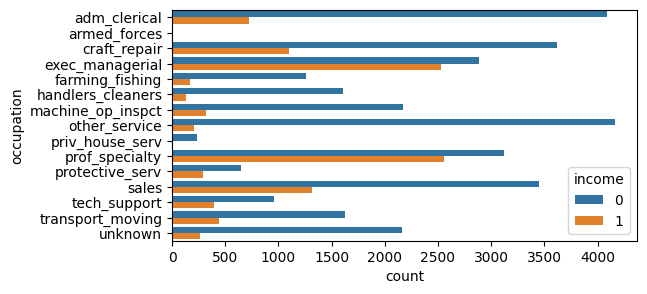

In [55]:
plt.figure(figsize=(6,3))
sns.countplot(y="occupation", hue="income", data=df)



- ANAMOLY --- Some individuals in high-paying roles still fall in <=50K category

### Income vs capital_gain

<Axes: xlabel='income', ylabel='capital_gain'>

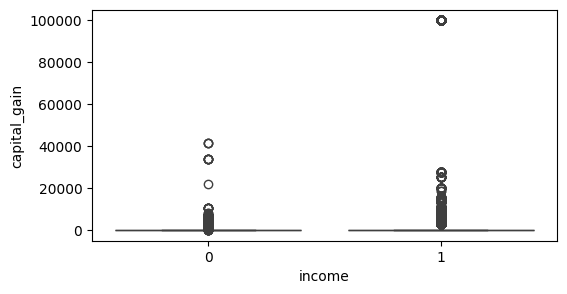

In [56]:
plt.figure(figsize=(6,3))
sns.boxplot(x="income", y="capital_gain", data=df)


- KEY ANOMALY
- A few individuals with high capital gain still fall under <=50K
- Some high-income individuals have zero capital gain, indicating multiple income sources

## Segmentation analysis

### Relationship Segmentation

In [ ]:
df.groupby("relationship")["income"].mean().sort_values(ascending=False)

- Being in a marital/family role strongly increases income probability
- Wife slightly exceeds Husband, which is unexpected and worth noting

### Marital Status Segmentation

In [ ]:
df.groupby("marital_status")["income"].mean().sort_values(ascending=False)

- Married individuals (especially married_civ_spouse ~46%) have much higher income probability
- married_af_spouse (~38%) is lower than expected compared to married_civ_spouse

### occupation Segmentation

In [ ]:
df.groupby("occupation")["income"].mean().sort_values(ascending=False)

- High-skill roles (exec_managerial ~47%, prof_specialty ~45%) have the highest income probability
- armed_forces (~33%) appears relatively high despite likely small sample size

### education + occupation

In [ ]:
df.groupby(["education", "occupation"])["income"].mean()

- Higher education combined with high-skill occupations leads to higher income probability
- Some low-education groups (e.g., 10th with exec_managerial) still show moderate income, indicating exceptions due to job role or experience